Name: MD MASHROOR ZILAN SNIGDHO

Email: snigdho2111@gmail.com

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.datasets import load_wine

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.metrics import confusion_matrix,classification_report
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [ ]:
df = pd.read_csv('adult_income.csv')

df.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
11184,41,State-gov,75409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,White,Female,0,0,40,United-States,>50K
1340,28,State-gov,225904,Prof-school,15,Never-married,Prof-specialty,Unmarried,White,Male,0,0,40,United-States,<=50K
39900,32,Private,226010,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,60,United-States,<=50K.
28656,34,Private,85374,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
11454,25,Private,247006,Assoc-acdm,12,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,<=50K
47473,55,Self-emp-inc,264453,Assoc-voc,11,Divorced,Exec-managerial,Unmarried,White,Male,0,0,30,United-States,<=50K.
37337,23,?,44793,HS-grad,9,Never-married,?,Not-in-family,White,Male,0,0,40,United-States,<=50K.
46540,60,Private,290754,HS-grad,9,Divorced,Machine-op-inspct,Not-in-family,White,Female,0,0,40,?,<=50K.
38039,18,Private,151747,11th,7,Never-married,Other-service,Own-child,White,Male,0,0,40,United-States,<=50K.
37663,33,Private,109920,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Black,Female,0,0,40,United-States,<=50K.


**Question 1: Exploratory Data Analysis (EDA) -20**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.shape

(48842, 15)

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.duplicated().sum()

np.int64(29)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(48813, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48813 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48813 non-null  int64 
 1   workclass       48813 non-null  object
 2   fnlwgt          48813 non-null  int64 
 3   education       48813 non-null  object
 4   education-num   48813 non-null  int64 
 5   marital-status  48813 non-null  object
 6   occupation      48813 non-null  object
 7   relationship    48813 non-null  object
 8   race            48813 non-null  object
 9   sex             48813 non-null  object
 10  capital-gain    48813 non-null  int64 
 11  capital-loss    48813 non-null  int64 
 12  hours-per-week  48813 non-null  int64 
 13  native-country  48813 non-null  object
 14  income          48813 non-null  object
dtypes: int64(6), object(9)
memory usage: 6.0+ MB


In [ ]:
df.drop(['fnlwgt'], axis = 1)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,?,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [ ]:
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

In [ ]:
df[cat_cols].apply(lambda col: col.str.contains('?', regex=False)).sum()

,0
workclass,2799
education,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0
native-country,856


In [ ]:
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)
df = df.replace('?', 'Missing')

In [ ]:
df.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
44967,42,Self-emp-not-inc,54583,Bachelors,13,Divorced,Prof-specialty,Unmarried,White,Female,0,0,30,United-States,<=50K.
37999,19,Private,182590,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,40,United-States,<=50K.
13453,25,Private,172581,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States,<=50K
23497,60,State-gov,114060,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,<=50K
43559,19,Private,100669,Assoc-voc,11,Never-married,Craft-repair,Own-child,Asian-Pac-Islander,Male,0,0,20,United-States,<=50K.
38148,65,Missing,369902,HS-grad,9,Widowed,Missing,Not-in-family,White,Female,0,0,8,United-States,<=50K.
34990,55,Private,401473,Masters,14,Widowed,Exec-managerial,Not-in-family,White,Female,0,0,40,United-States,>50K.
24016,19,Private,574271,HS-grad,9,Never-married,Handlers-cleaners,Own-child,White,Male,0,0,28,United-States,<=50K
33822,42,Private,107563,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,>50K.
39890,46,Private,155509,Bachelors,13,Separated,Prof-specialty,Unmarried,Black,Female,0,0,32,Jamaica,<=50K.


In [ ]:
df['income'].value_counts()

,count
income,
<=50K,24698
<=50K.,12430
>50K,7839
>50K.,3846


In [ ]:
df['income'] = df['income'].str.replace('.', '', regex=False)

In [ ]:
df['income'].value_counts()

,count
income,
<=50K,37128
>50K,11685


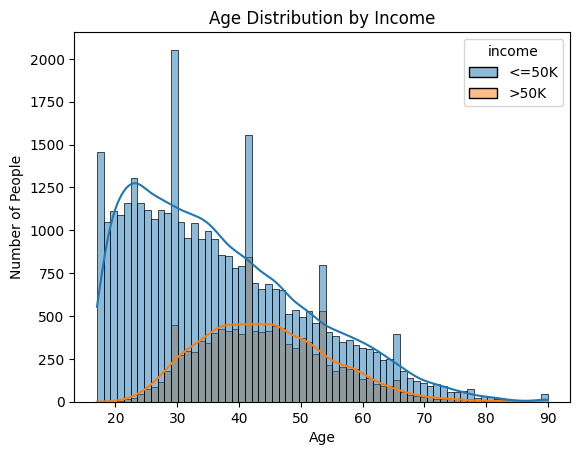

In [ ]:
sns.histplot(data=df, x='age', hue='income', kde=True)
plt.title('Age Distribution by Income')
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.show()

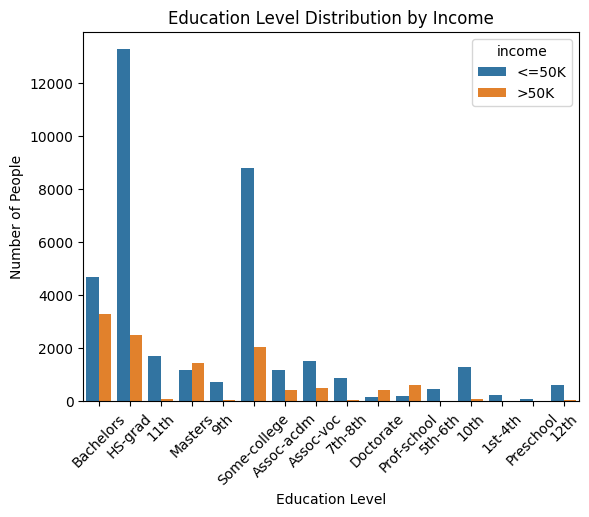

In [ ]:
sns.countplot(data=df, x='education', hue='income')
plt.title('Education Level Distribution by Income')
plt.xlabel('Education Level')
plt.ylabel('Number of People')
plt.xticks(rotation=45)
plt.show()

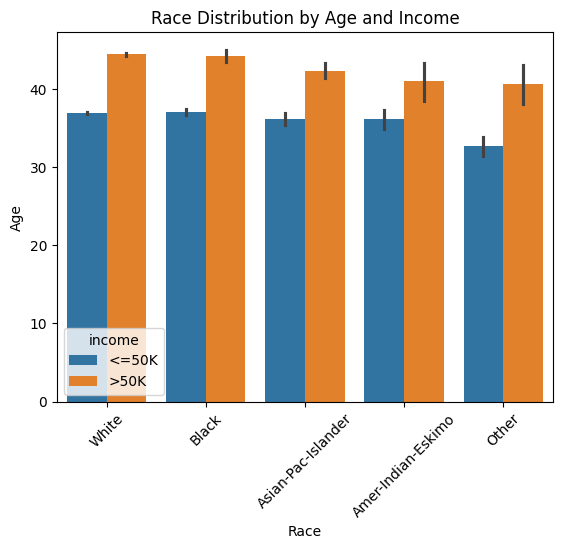

In [ ]:
sns.barplot(data=df, x='race', y='age', hue='income')
plt.title('Race Distribution by Age and Income')
plt.xlabel('Race')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.show()

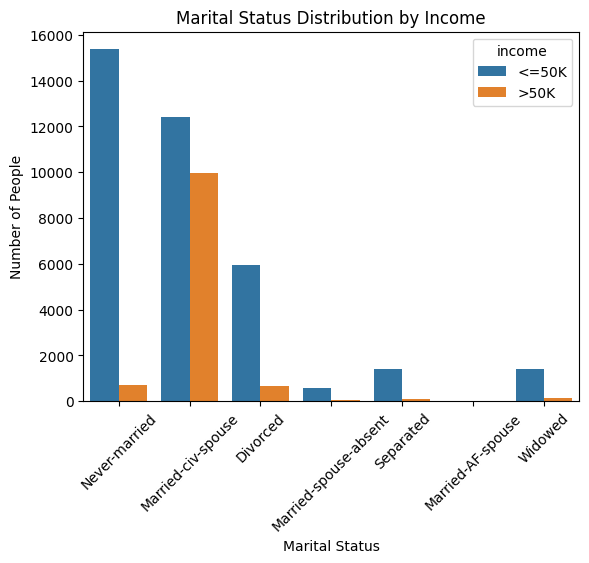

In [ ]:
sns.countplot(data=df, x='marital-status', hue='income')
plt.title('Marital Status Distribution by Income')
plt.xlabel('Marital Status')
plt.ylabel('Number of People')
plt.xticks(rotation=45)
plt.show()


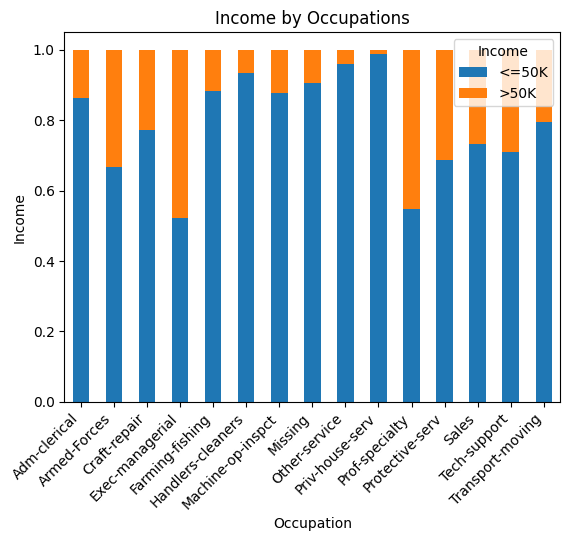

In [ ]:
pd.crosstab(df['occupation'], df['income'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Income by Occupations')
plt.xlabel('Occupation')
plt.ylabel('Income')
plt.legend(title='Income')
plt.xticks(rotation=45, ha='right')

plt.show()

In [ ]:
df.groupby('relationship')['income'].value_counts(normalize=True)

relationship    income
Husband         <=50K     0.551271
                >50K      0.448729
Not-in-family   <=50K     0.898464
                >50K      0.101536
Other-relative  <=50K     0.965471
                >50K      0.034529
Own-child       <=50K     0.985348
                >50K      0.014652
Unmarried       <=50K     0.939696
                >50K      0.060304
Wife            <=50K     0.531103
                >50K      0.468897
Name: proportion, dtype: float64

In [ ]:
df.groupby('workclass')['income'].value_counts(normalize=True)

workclass         income
Federal-gov       <=50K     0.608240
                  >50K      0.391760
Local-gov         <=50K     0.704401
                  >50K      0.295599
Missing           <=50K     0.905323
                  >50K      0.094677
Never-worked      <=50K     1.000000
Private           <=50K     0.782018
                  >50K      0.217982
Self-emp-inc      >50K      0.553719
                  <=50K     0.446281
Self-emp-not-inc  <=50K     0.721057
                  >50K      0.278943
State-gov         <=50K     0.732458
                  >50K      0.267542
Without-pay       <=50K     0.904762
                  >50K      0.095238
Name: proportion, dtype: float64

In [ ]:
df.groupby('education')['income'].value_counts(normalize=True)

education     income
10th          <=50K     0.937365
              >50K      0.062635
11th          <=50K     0.949227
              >50K      0.050773
12th          <=50K     0.926829
              >50K      0.073171
1st-4th       <=50K     0.967347
              >50K      0.032653
5th-6th       <=50K     0.946850
              >50K      0.053150
7th-8th       <=50K     0.935010
              >50K      0.064990
9th           <=50K     0.945767
              >50K      0.054233
Assoc-acdm    <=50K     0.742036
              >50K      0.257964
Assoc-voc     <=50K     0.746602
              >50K      0.253398
Bachelors     <=50K     0.586908
              >50K      0.413092
Doctorate     >50K      0.725589
              <=50K     0.274411
HS-grad       <=50K     0.841415
              >50K      0.158585
Masters       >50K      0.549322
              <=50K     0.450678
Preschool     <=50K     0.987805
              >50K      0.012195
Prof-school   >50K      0.739808
              <=50K     0.260192
Some-college  <=50K     0.810286
              >50K      0.189714
Name: proportion, dtype: float64

In [ ]:
df.groupby('occupation')['income'].value_counts(normalize=True)

occupation         income
Adm-clerical       <=50K     0.863053
                   >50K      0.136947
Armed-Forces       <=50K     0.666667
                   >50K      0.333333
Craft-repair       <=50K     0.773539
                   >50K      0.226461
Exec-managerial    <=50K     0.522025
                   >50K      0.477975
Farming-fishing    <=50K     0.883658
                   >50K      0.116342
Handlers-cleaners  <=50K     0.933366
                   >50K      0.066634
Machine-op-inspct  <=50K     0.877112
                   >50K      0.122888
Missing            <=50K     0.905660
                   >50K      0.094340
Other-service      <=50K     0.958528
                   >50K      0.041472
Priv-house-serv    <=50K     0.987500
                   >50K      0.012500
Prof-specialty     <=50K     0.548727
                   >50K      0.451273
Protective-serv    <=50K     0.686673
                   >50K      0.313327
Sales              <=50K     0.732013
                   >50K      0.267987
Tech-support       <=50K     0.709343
                   >50K      0.290657
Transport-moving   <=50K     0.795754
                   >50K      0.204246
Name: proportion, dtype: float64

In [ ]:
df.groupby('sex')['income'].value_counts(normalize=True)

sex     income
Female  <=50K     0.890681
        >50K      0.109319
Male    <=50K     0.696117
        >50K      0.303883
Name: proportion, dtype: float64

In [ ]:
df.groupby('native-country')['income'].value_counts(normalize=True)

native-country  income
Cambodia        <=50K     0.678571
                >50K      0.321429
Canada          <=50K     0.653846
                >50K      0.346154
China           <=50K     0.704918
                            ...   
United-States   >50K      0.244054
Vietnam         <=50K     0.918605
                >50K      0.081395
Yugoslavia      <=50K     0.652174
                >50K      0.347826
Name: proportion, Length: 83, dtype: float64

In [ ]:
df.groupby('race')['income'].value_counts(normalize=True)

race                income
Amer-Indian-Eskimo  <=50K     0.882979
                    >50K      0.117021
Asian-Pac-Islander  <=50K     0.730567
                    >50K      0.269433
Black               <=50K     0.879137
                    >50K      0.120863
Other               <=50K     0.876847
                    >50K      0.123153
White               <=50K     0.745903
                    >50K      0.254097
Name: proportion, dtype: float64

In [ ]:
df.groupby('marital-status')['income'].value_counts(normalize=True)

marital-status         income
Divorced               <=50K     0.898793
                       >50K      0.101207
Married-AF-spouse      <=50K     0.621622
                       >50K      0.378378
Married-civ-spouse     <=50K     0.553817
                       >50K      0.446183
Married-spouse-absent  <=50K     0.907643
                       >50K      0.092357
Never-married          <=50K     0.954466
                       >50K      0.045534
Separated              <=50K     0.935294
                       >50K      0.064706
Widowed                <=50K     0.915679
                       >50K      0.084321
Name: proportion, dtype: float64

Top 3 features (ranked):

1. Education Level:
The most number of people earning more than 50000 salary are with a bachelor's degree which can be seen from the countplot. The percentage is 41% among all the bachelor degree holders. Those who have education level of "Prof-school" has the highest percentage among themselves to earn more than 50000. The percentage is 73.98%. A university degree helps to earn more.

2. Martial Status:
The people who have martial status of "Married-civ-spouse" has the highest percentage of earning more than 50000. It can be seen from both the countplot and descriptive statistics. The percentage is 44%, which is the highest among all. Marrying a civilian spouse helps earn more.

3. Occupation:
"Exec-managerial" occupation has the highest percentage of 47% while "Prof-Speciality" has 45% of people who earn more than 50000. If the role is special or high level, it helps to earn a lot.


**Question 2: Preprocessing Pipeline Design (Regression) - 20**

In [ ]:
df.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
8746,47,Private,183522,Some-college,10,Married-civ-spouse,Exec-managerial,Wife,Black,Female,0,0,40,United-States,>50K
6717,52,Private,181901,HS-grad,9,Married-spouse-absent,Farming-fishing,Other-relative,White,Male,0,0,20,Mexico,<=50K
44773,32,Private,198901,10th,6,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
34210,52,Private,254680,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,99,United-States,<=50K
44291,19,Private,287380,Some-college,10,Never-married,Handlers-cleaners,Own-child,White,Male,0,0,27,United-States,<=50K


In [ ]:
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss']
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

In [ ]:
X = df.drop('hours-per-week', axis=1)
y = df['hours-per-week']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
num_pipeine = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# The "median" strategy is used here because it's best against outliers.
# StandardScaler is important to standardized the data by scaling to variance instead of mean.


cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# "most_frequent" strategy will find the most used value to impute.
# OneHotEncoder will convert the categories into unique binary values.

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeine, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'education-num', 'capital-gain',
                                  'capital-loss']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'education', 'marital-status',
                                  'occupation', 'relationship', 'race', 'sex',
                                  'native-country'])])

**Question 3: Regression Modeling & Evaluation - 20**

In [ ]:
lin_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

lin_pipeline.fit(X_train, y_train)

lin_pred = lin_pipeline.predict(X_test)

lin_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education-num',
                                                   'capital-gain',
                                                   'capital-loss']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('regressor', LinearRegression())])

In [ ]:
sgd_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', SGDRegressor(random_state=42))
    ]
)

sgd_pipeline.fit(X_train, y_train)

sgd_pred = sgd_pipeline.predict(X_test)

sgd_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education-num',
                                                   'capital-gain',
                                                   'capital-loss']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('regressor', SGDRegressor(random_state=42))])

In [ ]:
lin_r2 = r2_score(y_test, lin_pred)
lin_mae = mean_absolute_error(y_test, lin_pred)
lin_mse = mean_squared_error(y_test, lin_pred)

print(f'Linear Regression Metrics:')
print(f'R2 Score: {lin_r2:0.4f}')
print(f'Mean Absolute Error: {lin_mae:0.4f}')
print(f'Mean Squared Error: {lin_mse:0.4f}')

Linear Regression Metrics:
R2 Score: 0.1830
Mean Absolute Error: 7.7557
Mean Squared Error: 124.7762


In [ ]:
sgd_r2 = r2_score(y_test, sgd_pred)
sgd_mae = mean_absolute_error(y_test, sgd_pred)
sgd_mse = mean_squared_error(y_test, sgd_pred)

print(f'\nSGD Regression Metrics:')
print(f'R2 Score: {sgd_r2:0.4f}')
print(f'Mean Absolute Error: {sgd_mae:0.4f}')
print(f'Mean Squared Error: {sgd_mse:0.4f}')


SGD Regression Metrics:
R2 Score: 0.1809
Mean Absolute Error: 7.7376
Mean Squared Error: 125.0986


In [ ]:
compare_metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'SGD Regression'],
    'R2 Score': [lin_r2, sgd_r2],
    "Mean Absolute Error": [lin_mae, sgd_mae],
    "Mean Squared Error": [lin_mse, sgd_mse]
})

compare_metrics

,Model,R2 Score,Mean Absolute Error,Mean Squared Error
0,Linear Regression,0.183014,7.755676,124.776158
1,SGD Regression,0.180903,7.737564,125.098591



The model which is better should have  -
- Higher R2 score
- Lower Mean Absolute Error
- Lower Mean Squared Error

In this case, Linear Regression performs better since it has a higher R2 score, and lower MSE but slightly higher MAE compared to SGD Regression. Linear Regression dominates in 2 metrics here.


**Question 4: Classification Pipeline & Error Analysis -20**

In [ ]:
num_feats = ['age', 'education-num', 'capital-gain', 'capital-loss']
cat_feats = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

In [ ]:
X = df.drop('income', axis=1)
y = df['income']

In [ ]:
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_feats),
        ('cat', cat_pipeline, cat_feats)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
log_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]
)


log_pipeline.fit(X_train, y_train)

log_pred = log_pipeline.predict(X_test)

log_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education-num',
                                                   'capital-gain',
                                                   'capital-loss']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
log_pred

array(['<=50K', '<=50K', '<=50K', ..., '>50K', '<=50K', '<=50K'],
      dtype=object)

In [ ]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred, pos_label='>50K')
log_recall = recall_score(y_test, log_pred, pos_label='>50K')

print(f'Accuracy: {log_accuracy:0.4f}')
print(f'Precision: {log_precision:0.4f}')
print(f'Recall: {log_recall:0.4f}')

Accuracy: 0.8528
Precision: 0.7391
Recall: 0.5952


**Question 5: Hyperparameter Tuning & Model Comparison**

In [ ]:
knn_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('knn', KNeighborsClassifier())
    ]
)

knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education-num',
                                                   'capital-gain',
                                                   'capital-loss']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('knn', KNeighborsClassifier())])

In [ ]:
grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

gridSearchCV = GridSearchCV(
    estimator=knn_model,
    param_grid=grid,
    cv=3,
    n_jobs=-1
)

gridSearchCV.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_scorer.py", line 472, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py", line 1199, in score
    return self.steps[-1][1].score(Xt, y, **score_params)
           ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py", line 446, in score
    return super().score(X, y, sample_weight)
           ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^

In [ ]:
best_params = gridSearchCV.best_params_

print(f'Best Parameters: {best_params}')

In [ ]:
model = gridSearchCV.best_estimator_

model

In [ ]:
knn_accuracy = accuracy_score(y_test, model.predict(X_test))
knn_precision = precision_score(y_test, model.predict(X_test), pos_label='>50K')
knn_recall = recall_score(y_test, model.predict(X_test), pos_label='>50K')

print(f'Accuracy: {knn_accuracy:0.4f}')
print(f'Precision: {knn_precision:0.4f}')
print(f'Recall: {knn_recall:0.4f}')


In [ ]:
compare_metrics = pd.DataFrame({
    'Model': ['Logistic Regression', 'K-Nearest Neighbors'],
    'Accuracy': [log_accuracy, knn_accuracy],
    'Precision': [log_precision, knn_precision],
    'Recall': [log_recall, knn_recall]
})

compare_metrics